In [1]:
# --- Бібліотеки для даної роботи ---
try:
    import markdown, numpy, pandas, matplotlib, plotly, nbformat, pyvis, ipycytoscape, diagrams
    print("Бібліотеки вже встановлені. Пропускаємо інсталяцію.")
except ImportError:
    print("Встановлюємо бібліотеки...")
    %pip install markdown numpy pandas matplotlib plotly nbformat pyvis ipycytoscape diagrams

Бібліотеки вже встановлені. Пропускаємо інсталяцію.


# **Домашнє завдання: Проектування розподіленої системи кешування (Відеоплатформа - 2BeSmart)**

## **Частина 1: Аналіз вимог та оцінка масштабу**

### 1. Back-of-the-Envelope розрахунки
Для розрахунків зробимо базове припущення: з 100 млн щомісячних активних користувачів (MAU), щоденно активними є близько 50% (DAU = 50 млн). Це стандартна метрика для подібних платформ.

**А) Розрахунок розміру одного відео:**
* Тривалість: 5 хвилин = 300 секунд.
* Бітрейт (якість): 5 Мбіт/с.

$$\text{Обсяг (Мбіт)} = 300 \text{ с} \times 5 \text{ Мбіт/с} = 1500 \text{ Мбіт}$$
$$\text{Обсяг (МБ)} = \frac{1500 \text{ Мбіт}}{8 \text{ біт/байт}} = \mathbf{187.5 \text{ МБ}}$$

**Б) Очікуваний обсяг даних для зберігання (за 1 день):**
* **Відеофайли:** $$500,000 \text{ відео} \times 187.5 \text{ МБ} \approx 93,750,000 \text{ МБ} \approx \mathbf{93.75 \text{ ТБ/день}}$$
* **Метадані:** $$500,000 \text{ відео} \times 2 \text{ КБ} = 1,000,000 \text{ КБ} \approx \mathbf{1 \text{ ГБ/день}}$$
* **Коментарі:** $$500,000 \text{ відео} \times 10 \text{ ком.} \times 100 \text{ байт} = 500,000,000 \text{ байт} \approx \mathbf{500 \text{ МБ/день}}$$

*Річний приріст сховища (Storage):* $$\text{Storage}_{year} = 93.75 \text{ ТБ} \times 365 \approx \mathbf{34.2 \text{ Петабайти (ПБ) на рік}}$$
*(Примітка: Розрахунок наведено тільки для оригіналів відео, без урахування реплікації та різних форматів якості, які збільшать цю цифру у 3-4 рази).*

**В) Пропускна здатність мережі (Network Bandwidth):**
* Кількість переглядів: $50,000,000 \text{ (DAU)} \times 5 \text{ переглядів} = 250,000,000 \text{ переглядів/день}$
* Щоденний вихідний трафік (Egress): $250,000,000 \times 187.5 \text{ МБ} \approx \mathbf{46.8 \text{ ПБ/день}}$

Розрахунок необхідної пропускної здатності (в бітах на секунду):
$$\text{Bandwidth} = \frac{46.8 \times 10^{15} \text{ байт} \times 8 \text{ біт}}{86400 \text{ секунд}} \approx \mathbf{4.3 \text{ Tbps (Терабіт на секунду)}}$$
*(Цей колосальний обсяг трафіку прямо вказує на абсолютну необхідність використання глобальної CDN мережі).*

**Г) Необхідні обчислювальні ресурси (QPS - Queries Per Second):**
* **Read QPS (Перегляди):** $\frac{250,000,000}{86400} \approx \mathbf{2,893 \text{ запитів/сек}}$ (середнє). Пікове навантаження (Peak QPS) $\approx \mathbf{5,786 \text{ запитів/сек}}$.
* **Write QPS (Завантаження відео):** $\frac{500,000}{86400} \approx \mathbf{5.8 \text{ запитів/сек}}$ (це важкі I/O операції, що вимагають асинхронної обробки).
* **Write QPS (Коментарі):** $\frac{5,000,000}{86400} \approx \mathbf{58 \text{ запитів/сек}}$.

---

### 2. Аналіз нефункціональних вимог (CAP-теорема та PACELC)
Для відеоплатформи "2BeSmart" найкритичнішими вимогами є **Доступність (Availability)** та **Стійкість до розділення (Partition Tolerance)**. 

Згідно з **CAP-теоремою**, у розподіленій системі під час мережевого збою ми маємо обрати між доступністю та консистентністю (узгодженістю). Наша система однозначно обирає **AP (Availability + Partition Tolerance)** з підходом **Eventual Consistency** (узгодженість у кінцевому підсумку).

Більше того, застосовуючи теорему **PACELC**, ми визначаємо поведінку системи і в нормальному стані. Наш вибір — **PA/EL**:
* **PA** (у разі Partition обираємо Availability): Якщо зв'язок між дата-центрами обірветься, користувачі все одно повинні мати змогу дивитися відео, навіть якщо коментарі тимчасово не синхронізуються.
* **EL** (Else обираємо Latency): За нормальної роботи системи для нас важливіша мінімальна затримка (Latency), ніж абсолютна узгодженість (Consistency). Ми готові віддати клієнту відео з кешу, навіть якщо лічильник переглядів на ньому ще не оновився.

**Обґрунтування:**
1. **Бізнес-цінність:** Якщо користувач не зможе відкрити відео або сторінка завантажуватиметься довго (втрата доступності або висока латентність), він піде з платформи. Це пряма втрата грошей.
2. **Толерантність до затримок даних:** Якщо користувач залишив коментар, або кількість лайків оновиться для інших на 5 секунд пізніше — це абсолютно некритично для UX. Ніхто не помітить, що в одного користувача відео має 1 000 000 переглядів, а в іншого — 1 000 005. 
3. *Виняток:* Суворої консистентності (CP) вимагатиме лише вузька підсистема — фінансові транзакції (купівля підписки або донати авторам), яка буде ізольована в окремому реляційному домені.

<hr style="height: 15px; border: none; background: linear-gradient(to right, #007bff, #6610f2, #e83e8c, #fd7e14, #ffc107, #28a745); border-radius: 2px;">

## **Частина 2: Проектування моделі даних платформи «2BeSmart»**

Для платформи такого масштабу (50 млн DAU, 500 тис. нових відео щодня) використання єдиної бази даних є неможливим. Ми застосуємо підхід **Polyglot Persistence**, обравши спеціалізовані моделі даних для кожної сутності системи.

### 1. Користувачі (Users)
* **Модель даних:** Реляційна база даних (PostgreSQL).
* **Обґрунтування:** Дані профілів користувачів, їхні налаштування безпеки, паролі та фінансова інформація (для підписок) мають чітку, незмінну структуру. Операції з акаунтами вимагають транзакційності та суворого дотримання ACID-властивостей.
* **Структура (Таблиця `users`):**
  * `user_id` (UUID, Primary Key)
  * `username` (VARCHAR)
  * `email` (VARCHAR, Unique Index)
  * `password_hash` (VARCHAR)
  * `created_at` (TIMESTAMP)
* **Узгодженість:** **Strong Consistency** (Строга узгодженість). Користувач не може змінити пароль, а через мілісекунду успішно увійти за старим.

---

### 2. Відео: Метадані та Файли
Оскільки відео складається з важкого бінарного файлу та описової інформації, ми розділяємо їхнє зберігання:

**А) Відеофайли (Video Blobs)**
* **Модель даних:** Object Storage (Amazon S3 / MinIO).
* **Обґрунтування:** Бінарні дані (BLOBs) розміром у сотні мегабайтів неефективно зберігати в традиційних БД. Об'єктне сховище ідеально масштабується та дозволяє напряму роздавати файли через глобальну мережу CDN.

**Б) Метадані відео**
* **Модель даних:** Документо-орієнтована БД (MongoDB).
* **Обґрунтування:** Метадані мають ієрархічну структуру (назва, масив тегів, вкладений об'єкт із посиланнями на файли різної якості). Документна модель дозволяє витягнути всю інформацію для рендерингу сторінки відео за один запит (Access-Pattern-Driven Design).
* **Структура (Колекція `videos`):**
  ```json
  {
    "_id": "v_8f73d...",
    "author_id": "user_id_from_postgres", 
    "title": "System Design in 10 minutes",
    "description": "...",
    "tags": ["IT", "System Design", "Architecture"],
    "media": {
      "1080p": "s3://bucket/videos/v_8f73d_1080p.mp4",
      "thumbnail": "s3://bucket/thumbs/v_8f73d.jpg"
    },
    "metrics": { "views": 1500000, "likes": 45000 },
    "upload_date": "2026-03-09T12:00:00Z"
  }
  ```

* **Узгодженість:** **Eventual Consistency** (Узгодженість у кінцевому підсумку). Оновлення кількості лайків чи переглядів може відставати на кілька секунд.

---

### 3. Коментарі (Comments)
* **Модель даних:** Wide-column сховище (Apache Cassandra).
* **Обґрунтування:** Коментарі — це безперервний і величезний потік даних (write-heavy). У платформи типу YouTube часто бувають різкі сплески (спайки) коментарів під вірусними відео. Cassandra ідеально справляється з екстремальними навантаженнями на запис і дозволяє дуже швидко витягувати коментарі блоками (пагінація).
* **Структура (Таблиця `comments_by_video`):**
  * `video_id` (Partition Key — гарантує, що всі коментарі одного відео лежать на одному фізичному вузлі).
  * `created_at` (Clustering Key, DESC — для автоматичного сортування від новіших до старіших).
  * `comment_id` (UUID)
  * `user_id` (UUID)
  * `text` (TEXT)
* **Узгодженість:** **Eventual Consistency**. Якщо новий коментар з'явиться в інших користувачів на секунду пізніше, це не порушить логіку роботи системи.

---

### 4. Історія переглядів та Рекомендації
* **Модель даних:** Графова БД (Neo4j).
* **Обґрунтування:** Головна цінність платформи "2BeSmart" — утримання уваги користувача через рекомендації ("ті, хто дивився це, також дивилися..."). Реляційні бази даних дуже повільно виконують запити на пошук зв'язків з багатьма рівнями вкладеності. Графова база робить обхід графа та пошук патернів миттєвим.
* **Структура (Граф):**
  * *Вузли (Nodes):* `User`, `Video`, `Category`.
  * *Ребра (Edges/Зв'язки):* `User -[WATCHED]-> Video`, `Video -[BELONGS_TO]-> Category`.
* **Узгодженість:** **Eventual Consistency**. Граф рекомендацій може оновлюватися в фоновому режимі (асинхронно).

---

### 5. ER-діаграма
```mermaid
erDiagram
    %% Зв'язки між базами даних
    POSTGRESQL_USERS ||--o{ MONGODB_VIDEOS : "author_id"
    POSTGRESQL_USERS ||--o{ CASSANDRA_COMMENTS : "user_id"
    MONGODB_VIDEOS ||--|{ AMAZON_S3_BLOBS : "media_urls"
    MONGODB_VIDEOS ||--o{ CASSANDRA_COMMENTS : "video_id"
    POSTGRESQL_USERS ||--o{ NEO4J_GRAPH : "User_Nodes"
    MONGODB_VIDEOS ||--o{ NEO4J_GRAPH : "Video_Nodes"

    POSTGRESQL_USERS {
        UUID user_id PK
        VARCHAR username
        VARCHAR email
        VARCHAR password_hash
        TIMESTAMP created_at
    }

    MONGODB_VIDEOS {
        String id PK
        UUID author_id FK
        String title
        String description
        Array tags
        Object media
    }

    AMAZON_S3_BLOBS {
        String s3_url PK
        Blob video_1080p
        Blob video_720p
        Blob thumbnail_jpg
    }

    CASSANDRA_COMMENTS {
        UUID video_id PK
        TIMESTAMP created_at PK
        UUID comment_id
        UUID user_id FK
        TEXT text
    }

    NEO4J_GRAPH {
        Node user_node
        Node video_node
        Edge watched_relation
    }
```

In [11]:
# Інтерактивна ER-подібна Модель
import ipycytoscape
from IPython.display import display

cyto = ipycytoscape.CytoscapeWidget(layout={'height': '750px'})

graph_data = {
    'nodes': [
        {'data': {'id': 'pg', 'color': '#336791', 
                  'name': 'PostgreSQL (Users)\n──────────────\n🔑 user_id\n👤 username\n📧 email\n🔒 password\n⚡ Strong Consist.'}},
        
        {'data': {'id': 'mongo', 'color': '#47A248', 
                  'name': 'MongoDB (Videos)\n──────────────\n🔑 _id\n🔗 author_id\n📝 title, desc\n🏷️ tags\n⚡ Eventual Consist.'}},
        
        {'data': {'id': 's3', 'color': '#FF9900', 
                  'name': 'Amazon S3 (Blobs)\n──────────────\n📁 1080p.mp4\n📁 720p.mp4\n🖼️ thumbnail.jpg\n⚡ High Availabil.'}},
        
        {'data': {'id': 'cass', 'color': '#1287B1', 
                  'name': 'Cassandra (Comments)\n──────────────\n🔑 video_id (PK)\n⏱️ created_at\n📝 text\n⚡ Eventual Consist.'}},
        
        {'data': {'id': 'neo', 'color': '#018BFF', 
                  'name': 'Neo4j (Recs)\n──────────────\n🔵 User\n -[WATCHED]->\n🔴 Video\n⚡ Eventual Consist.'}}
    ],
    'edges': [
        {'data': {'source': 'pg', 'target': 'mongo', 'label': 'Author FK'}},
        {'data': {'source': 'mongo', 'target': 's3', 'label': 'S3 URLs'}},
        {'data': {'source': 'pg', 'target': 'cass', 'label': 'Author FK'}},
        {'data': {'source': 'mongo', 'target': 'cass', 'label': 'Video FK'}},
        {'data': {'source': 'pg', 'target': 'neo', 'label': 'User Node'}},
        {'data': {'source': 'mongo', 'target': 'neo', 'label': 'Video Node'}}
    ]
}

cyto.graph.add_graph_from_json(graph_data)

cyto.set_style([
    {
        'selector': 'node',
        'css': {
            'content': 'data(name)',
            'text-wrap': 'wrap',
            'font-family': 'monospace',
            'font-size': '13px',
            'text-valign': 'center',
            'text-halign': 'center',
            'background-color': '#1E1E1E',
            'border-color': 'data(color)',
            'border-width': '4px',
            'color': '#E0E0E0',
            'shape': 'round-rectangle',
            'width': '230px',
            'height': '170px',
        }
    },
    {
        'selector': 'edge',
        'css': {
            'label': 'data(label)',
            'curve-style': 'bezier',
            'target-arrow-shape': 'triangle',
            'line-color': '#888888',
            'target-arrow-color': '#888888',
            'color': '#FFFFFF',
            'font-size': '12px',
            'text-background-color': '#1E1E1E',
            'text-background-opacity': 1,
            'width': 3,
            'arrow-scale': 2.0
        }
    }
])

cyto.set_layout(name='dagre', nodeSep=120, edgeSep=120, rankSep=140, rankDir='TB')
display(cyto)

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'nodeSep': 120, 'edgeSep': 120, 'rankSep': 140, 'rankDir': …

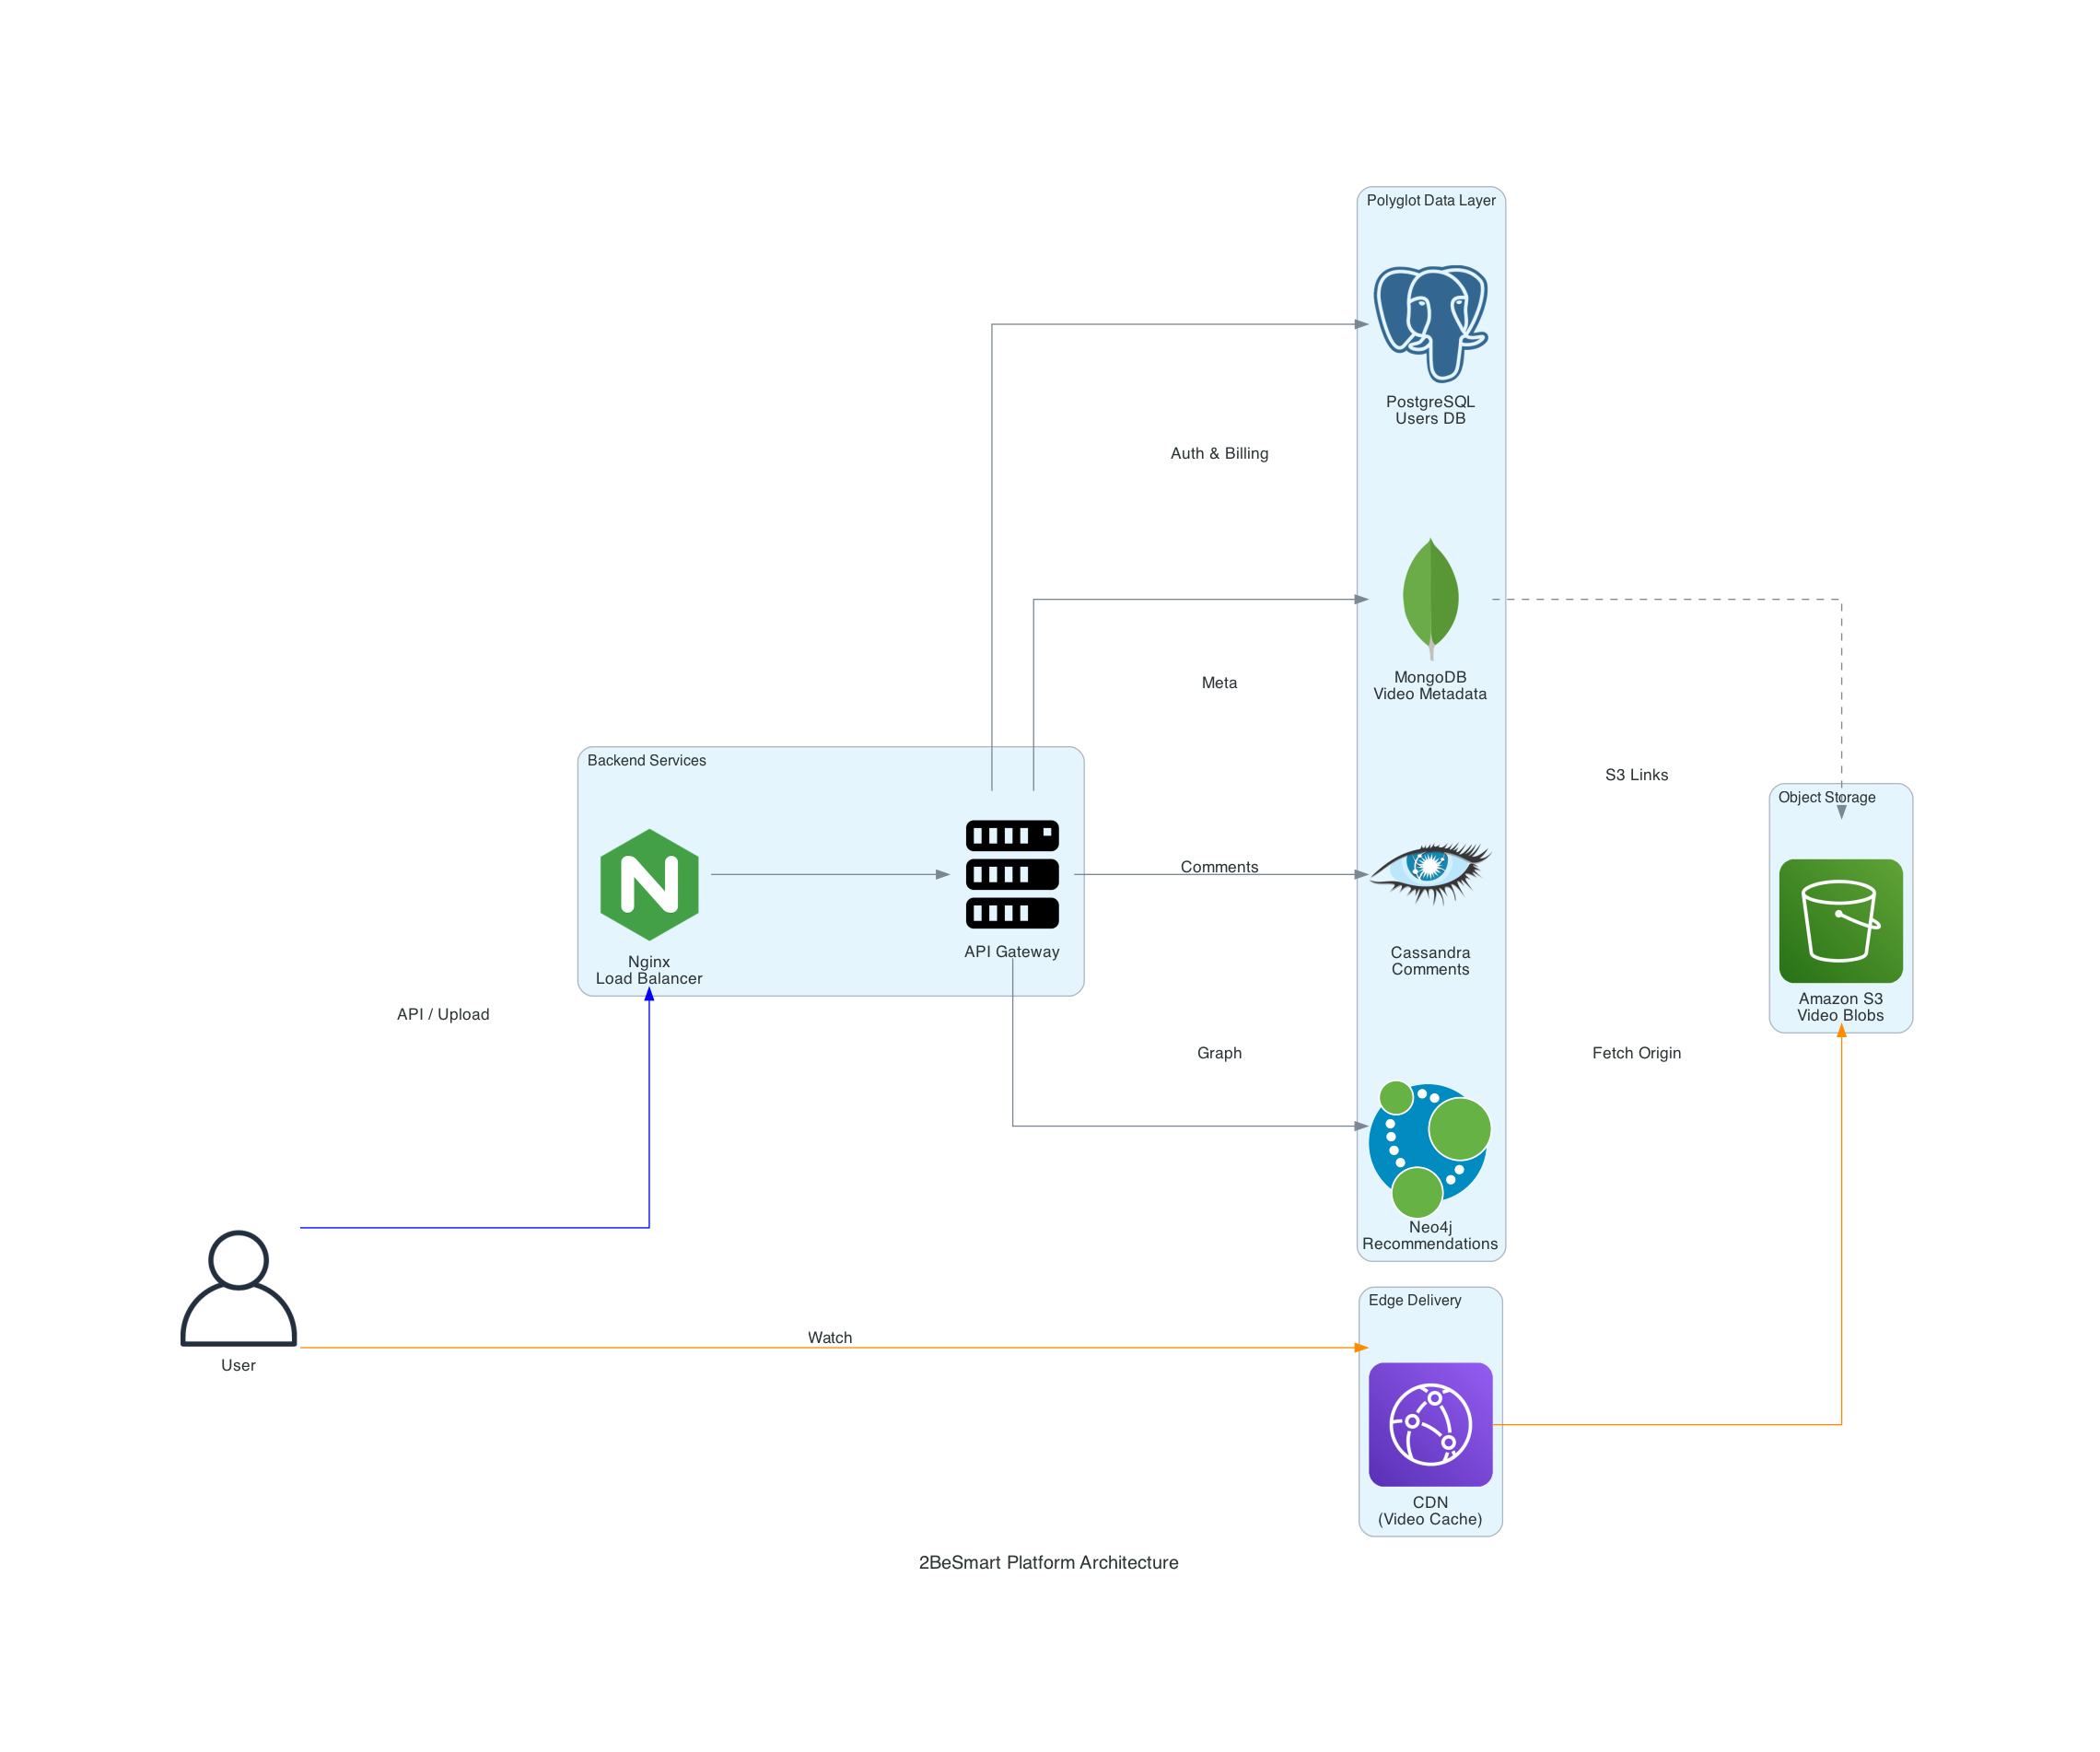

In [12]:
# Статична Інфраструктурна Архітектура
import os
import urllib.request
from IPython.display import Image, display
from diagrams import Diagram, Cluster, Edge
from diagrams.custom import Custom
from diagrams.onprem.client import User
from diagrams.aws.network import CloudFront
from diagrams.onprem.network import Nginx
from diagrams.onprem.compute import Server
from diagrams.onprem.database import PostgreSQL, MongoDB, Cassandra
from diagrams.aws.storage import S3

dir_project_files = "Project_Files"
os.makedirs(dir_project_files, exist_ok=True)

neo4j_url = "https://cdn.freebiesupply.com/logos/large/2x/neo4j-logo-png-transparent.png"
neo4j_icon_path = os.path.join(dir_project_files, "neo4j_icon.png")
urllib.request.urlretrieve(neo4j_url, neo4j_icon_path)

graph_attr = {
    "nodesep": "0.8",
    "ranksep": "2.2"
}

diagram_base_path = os.path.join(dir_project_files, "2besmart_arch")

try:
    with Diagram("2BeSmart Platform Architecture", show=False, direction="LR", filename=diagram_base_path, graph_attr=graph_attr):
        client = User("User")

        with Cluster("Edge Delivery"):
            cdn = CloudFront("CDN\n(Video Cache)")

        with Cluster("Backend Services"):
            lb = Nginx("Nginx\nLoad Balancer")
            api = Server("API Gateway")

        with Cluster("Object Storage"):
            s3 = S3("Amazon S3\nVideo Blobs") 

        with Cluster("Polyglot Data Layer"):
            pg = PostgreSQL("PostgreSQL\nUsers DB")
            mongo = MongoDB("MongoDB\nVideo Metadata")
            cass = Cassandra("Cassandra\nComments")
            neo = Custom("Neo4j\nRecommendations", "neo4j_icon.png")

        client >> Edge(color="darkorange", label="Watch") >> cdn
        cdn >> Edge(label="Fetch Origin", dir="both", color="darkorange") >> s3

        client >> Edge(color="blue", label="API / Upload") >> lb
        lb >> api

        api >> Edge(label="Auth & Billing") >> pg
        api >> Edge(label="Meta") >> mongo
        api >> Edge(label="Comments") >> cass
        api >> Edge(label="Graph") >> neo

        mongo >> Edge(label="S3 Links", style="dashed") >> s3

    final_image_path = f"{diagram_base_path}.png"
    display(Image(filename=final_image_path))

except Exception as e:
    print(f"\n   ❌ Сталася помилка під час генерації діаграми: {e}")

In [ ]:
# Інтерактивний "бульбашковий" Граф
import base64
import os
from pyvis.network import Network
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

net = Network(notebook=True, width="100%", height="600px", directed=True, cdn_resources='remote', bgcolor="#1e1e1e", font_color="white")
net.force_atlas_2based(gravity=-50)

# 1. Інфраструктура
net.add_node("User", label="👤 User", color="#888888", shape="ellipse", size=20)
net.add_node("CDN", label="🌐 CDN\n(Video Cache)", color="#8A2BE2", shape="box", size=25)
net.add_node("API", label="⚙️ API Gateway", color="#555555", shape="box", size=25)

# 2. Бази даних
net.add_node("PostgreSQL", label="PostgreSQL\n(Users)", color="#336791", shape="database", size=30, title="USERS (Relational DB)\n------------------------------\n🔑 user_id : UUID\n👤 username : VARCHAR\n📧 email : VARCHAR\n🔒 password_hash : VARCHAR\n* Strong Consistency")
net.add_node("MongoDB", label="MongoDB\n(Video Metadata)", color="#47A248", shape="database", size=30, title="VIDEOS (Document DB)\n------------------------------\n🔑 _id : String\n🔗 author_id : UUID\n📝 title, desc : String\n🏷️ tags : Array\n📊 metrics : Object\n* Eventual Consistency")
net.add_node("S3", label="Amazon S3\n(Video Blobs)", color="#E35128", shape="box", size=30, title="S3 BUCKET (Object Storage)\n------------------------------\n📁 1080p.mp4\n📁 720p.mp4\n🖼️ thumbnail.jpg")
net.add_node("Cassandra", label="Cassandra\n(Comments)", color="#1287B1", shape="database", size=30, title="COMMENTS (Wide-Column DB)\n------------------------------\n🔑 video_id (Partition Key)\n⏱️ created_at (Clustering Key)\n📝 text : String\n* Eventual Consistency")
net.add_node("Neo4j", label="Neo4j\n(Recommendations)", color="#008CC1", shape="database", size=30, title="RECOMMENDATIONS (Graph DB)\n------------------------------\n🔵 User -[WATCHED]-> 🔴 Video\n* Eventual Consistency")

# 3. Зв'язки (Шлях перегляду)
net.add_edge("User", "CDN", title="Watch Video", label="Watch", color="#ff9900")
net.add_edge("CDN", "S3", title="Fetch Origin (Cache Miss)", label="Fetch", color="#ff9900")

# 4. Зв'язки (Шлях API / Завантаження)
net.add_edge("User", "API", title="API Requests / Upload", label="API / Upload", color="#007BFF")
net.add_edge("API", "S3", title="Save Video File", label="Save File", color="#ff0000")
net.add_edge("API", "PostgreSQL", title="Auth & Billing", label="Auth", color="#aaaaaa")
net.add_edge("API", "MongoDB", title="Read/Write Metadata", label="Meta", color="#aaaaaa")
net.add_edge("API", "Cassandra", title="Write Heavy", label="Comments", color="#aaaaaa")
net.add_edge("API", "Neo4j", title="Graph Traversal", label="Graph", color="#aaaaaa")
net.add_edge("MongoDB", "S3", title="Містить посилання на файли", label="S3 URLs", color="#aaaaaa")

dir_project_files = "Project_Files"

try:
    os.makedirs(dir_project_files, exist_ok=True)
    file_path = os.path.join(dir_project_files, "2besmart_data_model.html")
    net.save_graph(file_path)

    with open(file_path, "r", encoding="utf-8") as f:
        html_content = f.read()

    b64_html = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')
    iframe_code = f'<iframe src="data:text/html;base64,{b64_html}" width="100%" height="620px" style="border:none;"></iframe>'

    display(HTML(iframe_code))

except Exception as e:
    print(f"\n   ❌ Сталася помилка: {e}")

<hr style="height: 15px; border: none; background: linear-gradient(to right, #007bff, #6610f2, #e83e8c, #fd7e14, #ffc107, #28a745); border-radius: 2px;">

## Частина 3: Розподілення даних (Реплікація та Шардування)

З огляду на цільове навантаження (50 млн DAU, сотні тисяч нових відео щодня), жодна база даних не зможе працювати на одному фізичному сервері. Ми застосовуємо стратегії горизонтального масштабування (Sharding) та відмовостійкості (Replication) індивідуально для кожної технології.

### 1. PostgreSQL (Користувачі та Білінг)
Оскільки кількість користувачів зростає передбачувано, а операції читання (авторизація, перевірка профілю) значно переважають над операціями запису (реєстрація, зміна пароля, оплата), ми фокусуємося на реплікації.
* **Реплікація:** Single-leader (Master-Slave) архітектура.
  * **Leader (Primary):** Приймає всі операції запису (`INSERT`, `UPDATE`).
  * **Followers (Read Replicas):** 2-3 вузли, які асинхронно копіюють дані з Лідера. Усі запити на читання балансуються між репліками.
* **Шардування:** На етапі 50 млн користувачів сучасний кластер PostgreSQL витримує навантаження без шардування (достатньо вертикального масштабування Leader-вузла та застосування Table Partitioning за датою реєстрації або регіоном).

### 2. MongoDB (Метадані відео)
Ця база даних зберігає інформацію про всі відео на платформі і є найбільш навантаженою точкою під час пошуку та генерації стрічки рекомендацій.
* **Реплікація:** Single-leader у вигляді Replica Set (мінімум 3 вузли: Primary, Secondary, Secondary). Забезпечує автоматичне відновлення (Automatic Failover): якщо Primary падає, один із Secondary вузлів миттєво обирається новим лідером (Leader Election).
* **Шардування:** Обов'язкове. Ми використовуємо **Hash-based sharding**.
  * **Shard Key:** Hashed `_id` (або `video_id`).
  * **Обґрунтування та Hot spots:** Хешування ID гарантує рівномірний розподіл документів по всіх шардах (фізичних серверах). Якби ми використали Range-based sharding за `author_id`, то популярні автори (наприклад, блогери-мільйонники) створювали б «гарячі точки» (Hotspots) на одному конкретному сервері, повністю перевантажуючи його під час випуску нового відео.
  * **Вторинні індекси:** Використовуємо локальне секціонування (Document-partitioned secondary indexes). Індекси для пошуку за тегами або назвою зберігаються локально на кожному шарді.

### 3. Cassandra (Коментарі)
Cassandra має децентралізовану (Leaderless) архітектуру з коробки, що робить її ідеальною для запису величезних обсягів даних під час спайків трафіку.
* **Реплікація:** Використовується стратегія Ring Topology з Replication Factor (RF) = 3. Кожен коментар автоматично копіюється на 3 різні фізичні вузли кластера. Consistency Level для читання та запису встановлюється на `QUORUM` (підтвердження від 2 з 3 вузлів).
* **Партиціювання (Шардування):**
  * Відбувається автоматично на основі нашого Partition Key (`video_id`). Дані розподіляються по кільцю вузлів (Consistent Hashing), гарантуючи, що всі коментарі до одного відео лежать поруч для миттєвого читання.
  * **Вирішення Hot spots:** Якщо відео стає вірусним, усі коментарі полетять на один вузол (оскільки ключ — `video_id`), що створить перевантаження. Щоб цього уникнути, ми додаємо "сіль" (Salting) до ключа: `video_id + month_year`. Це розмаже коментарі до супер-популярних відео по різних вузлах.

### 4. Amazon S3 (Відеофайли)
Об'єктне сховище від AWS бере на себе всі питання розподілення фізичних файлів під капотом.
* **Реплікація:** Дані автоматично реплікуються у межах одного регіону мінімум між трьома ізольованими зонами доступності (Availability Zones). Це гарантує довговічність об'єктів на рівні 99.99999993% (11 9's) та високу доступність навіть якщо один з дата-центрів вийде з ладу.

### 5. Neo4j (Граф Рекомендацій)
* **Реплікація:** Використовується Causal Clustering (Multi-leader підхід для консенсусу).
  * **Core Servers:** Забезпечують запис нових зв'язків (наприклад, коли користувач ставить лайк) за допомогою протоколу консенсусу Raft.
  * **Read Replicas:** Масштабуються горизонтально для обробки мільйонів важких запитів на обхід графа (Graph Traversal) під час формування стрічки рекомендацій для користувачів.

---

### 6. Обробка відмов та затримок (Failure Handling)
Щоб гарантувати безперебійну роботу 24/7, система має вбудовані механізми компенсації збоїв:

* **Відмова реплік (Follower Failure):**
  * Якщо падає Secondary вузол у MongoDB або Follower у PostgreSQL, запити на читання автоматично перенаправляються Load Balancer-ом на живі репліки.
  * У Cassandra (Leaderless) при падінні репліки сусідні вузли тимчасово зберігають дані для неї (Hinted Handoff) і віддають їх після її перезапуску (Read Repair).
* **Відмова лідера (Leader Failure):**
  * У MongoDB використовується механізм автоматичного відновлення (Automatic Failover). Вузли проводять "вибори" (Election), і один із Secondary за кілька секунд стає новим Primary. На час виборів запис тимчасово блокується, але читання продовжує працювати.
* **Replication lag (Затримка реплікації) та вплив на користувацький досвід:**
  * Оскільки ми використовуємо асинхронну реплікацію в PostgreSQL та MongoDB, існує вікно в кілька мілісекунд/секунд, коли дані на Фоловерах застарілі.
  * *Вплив на UX:* Якщо користувач змінив аватарку або назву свого відео і одразу оновив сторінку, запит на читання може потрапити на репліку, яка ще не оновилася (користувач побачить старі дані).
  * *Рішення:* Для критичних дій (оплата підписки, власні налаштування) ми використовуємо патерн "Read-your-own-writes" (читання власних записів), направляючи такі запити користувача виключно на Лідера протягом перших 10 секунд після оновлення. Для лічильників лайків та переглядів Replication lag є прийнятним і не руйнує UX.

### 7. Математичне обґрунтування та Візуалізація топологій

**Формула Hash-based секціонування (MongoDB):**
Щоб уникнути Hot spots, сервер, на який потрапить документ, обчислюється хеш-функцією:
$$\text{Shard ID} = \text{hash}(\text{video\_id}) \pmod{N}$$
*де $N$ — загальна кількість доступних шардів.*

**Математика консистентності (Cassandra Quorum):**
Для децентралізованої бази при Replication Factor ($N = 3$), використовується формула кворуму ($Q$):
$$Q = \lfloor \frac{N}{2} \rfloor + 1 = 2$$
Щоб уникнути читання застарілих даних (Stale Reads), система дотримується суворого правила перекриття читання та запису:
$$R + W > N$$
*Оскільки $2 + 2 > 3$, система гарантує, що вузол, з якого ми читаємо, завжди має найсвіжішу версію.*

**Схема 1: Single-Leader Реплікація (PostgreSQL / MongoDB)**

```mermaid
flowchart TD
    Client([Load Balancer /<br/>API Gateway])
    Leader[(Primary Node<br/>Запис і Читання)]
    Follower1[(Secondary Node 1<br/>Тільки Читання)]
    Follower2[(Secondary Node 2<br/>Тільки Читання)]

    Client -- "Writes (INSERT/UPDATE)" --> Leader
    Client -. "Reads (SELECT)" .-> Follower1
    Client -. "Reads (SELECT)" .-> Follower2
    Leader -- "Асинхронна реплікація (Replication Lag)" --> Follower1
    Leader -- "Асинхронна реплікація" --> Follower2
```

**Схема 2: Consistent Hashing та Leaderless Реплікація (Cassandra)**
```mermaid
flowchart LR
    subgraph Hash_Ring [Кільце Consistent Hashing]
        NodeA((Node A))
        NodeB((Node B))
        NodeC((Node C))
        NodeA --> NodeB --> NodeC --> NodeA
    end
    Data["Новий коментар<br/>Hash ключа = 45"] -->|Запис на координатор| NodeB
    NodeB -. "Асинхронна реплікація (+1)" .-> NodeC
    NodeB -. "Асинхронна реплікація (+2)" .-> NodeA
```

**Схема 3: Реплікація об'єктного сховища (Amazon S3)**

```mermaid
flowchart TD
    Client([Користувач/Завантаження відео])
    subgraph Region [AWS Region eu-central-1]
        subgraph AZ1 [Availability Zone A]
            S3A[(S3 Storage Node)]
        end
        subgraph AZ2 [Availability Zone B]
            S3B[(S3 Storage Node)]
        end
        subgraph AZ3 [Availability Zone C]
            S3C[(S3 Storage Node)]
        end
    end

    Client -->|Upload video.mp4| S3A
    S3A ==>|Синхронна реплікація| S3B
    S3A ==>|Синхронна реплікація| S3C
    
    style Region fill:#f9f9f9,stroke:#333,stroke-width:2px,stroke-dasharray: 5 5
    style AZ1 fill:#e6f3ff,stroke:#0066cc
    style AZ2 fill:#e6f3ff,stroke:#0066cc
    style AZ3 fill:#e6f3ff,stroke:#0066cc
```

**Схема 4: Causal Clustering (Neo4j)**

```mermaid
flowchart TD
    Client([API Gateway Клієнт])

    subgraph Core [1. Core Servers - Збереження та Raft Консенсус]
        %% Одна прозора розпірка = рівно 1 рядок відступу
        SpacerCore[" "]
        style SpacerCore fill:none,stroke:none,color:none
        
        SpacerCore ~~~ L[(Core Leader)]
        
        L <-->|Raft| F1[(Core Follower 1)]
        L <-->|Raft| F2[(Core Follower 2)]
        F1 <-->|Raft| F2
    end

    subgraph Replicas [2. Read Replicas - Важкі обчислення графа]
        %% Одна прозора розпірка = рівно 1 рядок відступу
        SpacerRep[" "]
        style SpacerRep fill:none,stroke:none,color:none
        
        SpacerRep ~~~ R1[(Read Replica 1)]
        
        R1 ~~~ R2[(Read Replica 2)]
        R2 ~~~ R3[(Read Replica N)]
    end

    Client -->|Всі Write-запити| L
    Client -.->|Read-запити Рекомендації| R1
    Client -.->|Read-запити Рекомендації| R2

    Core ===>|Асинхронна трансляція логів| Replicas
```